In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import yfinance as yf

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False
})

In [4]:
tickers = [
    "RELIANCE.NS", "HDFCBANK.NS", "INFY.NS", "TCS.NS",
    "MARUTI.NS", "SUNPHARMA.NS", "BAJFINANCE.NS",
    "ASIANPAINT.NS", "ONGC.NS", "ADANIENT.NS", "^NSEI"
]

START = "2019-01-01"
END = "2024-12-31"

In [5]:
raw = yf.download(tickers, start=START, end=END, auto_adjust=True)
close = raw["Close"]
print(close.shape)
close.head()

[*********************100%***********************]  11 of 11 completed


(1480, 11)


Ticker,ADANIENT.NS,ASIANPAINT.NS,BAJFINANCE.NS,HDFCBANK.NS,INFY.NS,MARUTI.NS,ONGC.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,
2019-01-01,155.306366,1295.010864,259.204132,504.392487,553.448303,7004.461426,94.748306,498.490601,402.755890,1582.165894,NaN
2019-01-02,152.936066,1306.104980,255.028549,499.790253,556.777222,6808.712402,93.823158,491.998260,408.794159,1599.211792,10792.500000
2019-01-03,150.615097,1310.826050,252.311478,495.868958,556.860474,6748.849609,90.856293,485.928284,405.124786,1579.796387,10672.250000
2019-01-04,150.664505,1308.512695,251.321259,497.195618,550.119568,6777.468750,92.961800,488.551941,402.988159,1560.588867,10727.349609
2019-01-07,149.380539,1318.096436,249.130981,497.946899,558.982544,6896.961426,94.333595,491.264435,400.201202,1578.091797,10771.799805


In [6]:
raw.to_csv("../data/raw/raw_data.csv")

In [7]:
# Check for fully empty columns
null_counts=close.isna().sum()
print(null_counts)

# Drop any ticker with >5% missing data
threshold = 0.05 * len(close)
clean=close.dropna(axis=1, thresh=len(close)-threshold)

# Forward fill remaining missing values
clean=clean.ffill()
print(f"\nRemaining nulls:\n{clean.isnull().sum()}")

Ticker
ADANIENT.NS      0
ASIANPAINT.NS    0
BAJFINANCE.NS    0
HDFCBANK.NS      0
INFY.NS          0
MARUTI.NS        0
ONGC.NS          0
RELIANCE.NS      0
SUNPHARMA.NS     0
TCS.NS           0
^NSEI            3
dtype: int64

Remaining nulls:
Ticker
ADANIENT.NS      0
ASIANPAINT.NS    0
BAJFINANCE.NS    0
HDFCBANK.NS      0
INFY.NS          0
MARUTI.NS        0
ONGC.NS          0
RELIANCE.NS      0
SUNPHARMA.NS     0
TCS.NS           0
^NSEI            1
dtype: int64


In [8]:
clean_columns = clean.columns.tolist()
print(f"\nCleaned tickers: {clean_columns}")


Cleaned tickers: ['ADANIENT.NS', 'ASIANPAINT.NS', 'BAJFINANCE.NS', 'HDFCBANK.NS', 'INFY.NS', 'MARUTI.NS', 'ONGC.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'TCS.NS', '^NSEI']


In [9]:
print(f"\nFinal dataset shape: {clean.shape}")


Final dataset shape: (1480, 11)


In [10]:
clean=clean.dropna()  # Drop any remaining rows with nulls

In [11]:
clean.to_csv("../data/raw/cleaned_data.csv")

In [12]:
print(clean[['ADANIENT.NS', '^NSEI']].head())
print(clean['^NSEI'].isna().sum())

Ticker      ADANIENT.NS         ^NSEI
Date                                 
2019-01-02   152.936066  10792.500000
2019-01-03   150.615097  10672.250000
2019-01-04   150.664505  10727.349609
2019-01-07   149.380539  10771.799805
2019-01-08   151.553345  10802.150391
0


In [13]:
clean.columns

Index(['ADANIENT.NS', 'ASIANPAINT.NS', 'BAJFINANCE.NS', 'HDFCBANK.NS',
       'INFY.NS', 'MARUTI.NS', 'ONGC.NS', 'RELIANCE.NS', 'SUNPHARMA.NS',
       'TCS.NS', '^NSEI'],
      dtype='str', name='Ticker')

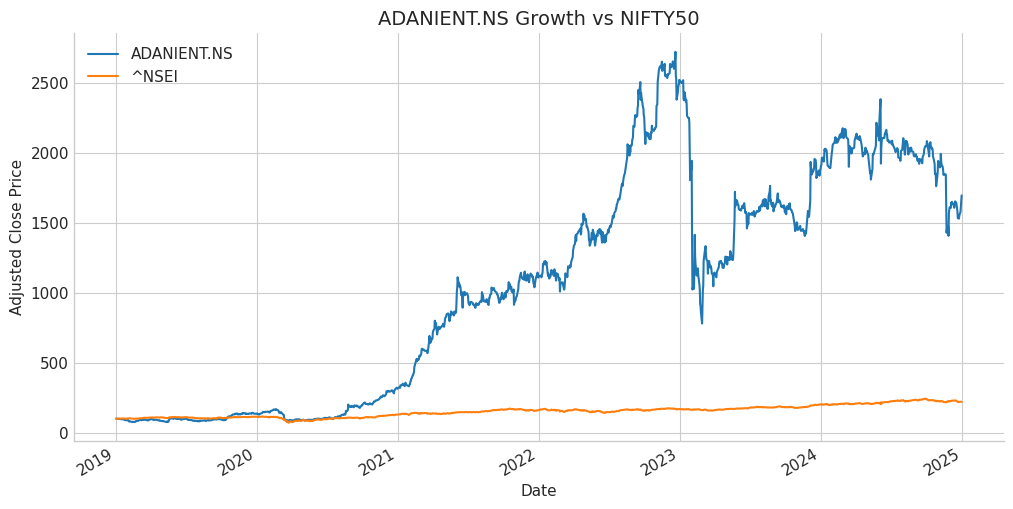

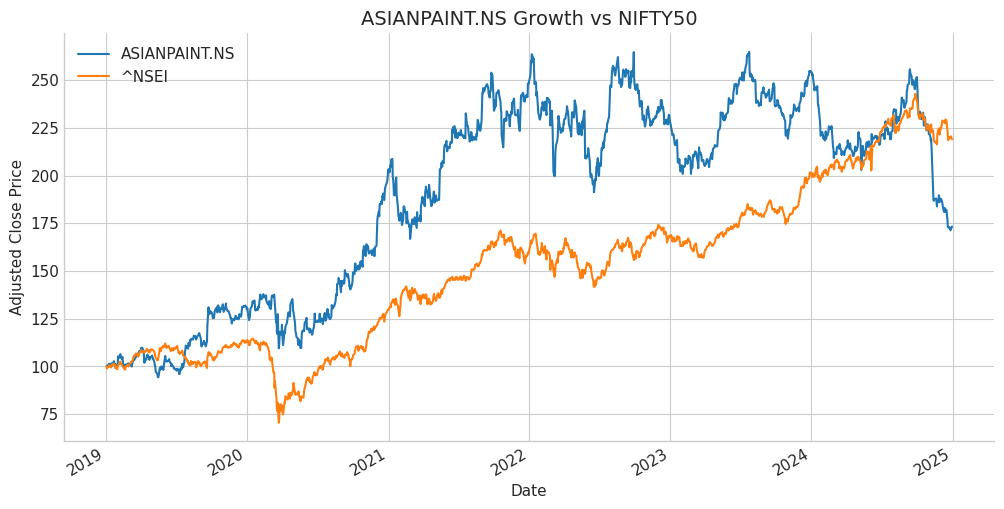

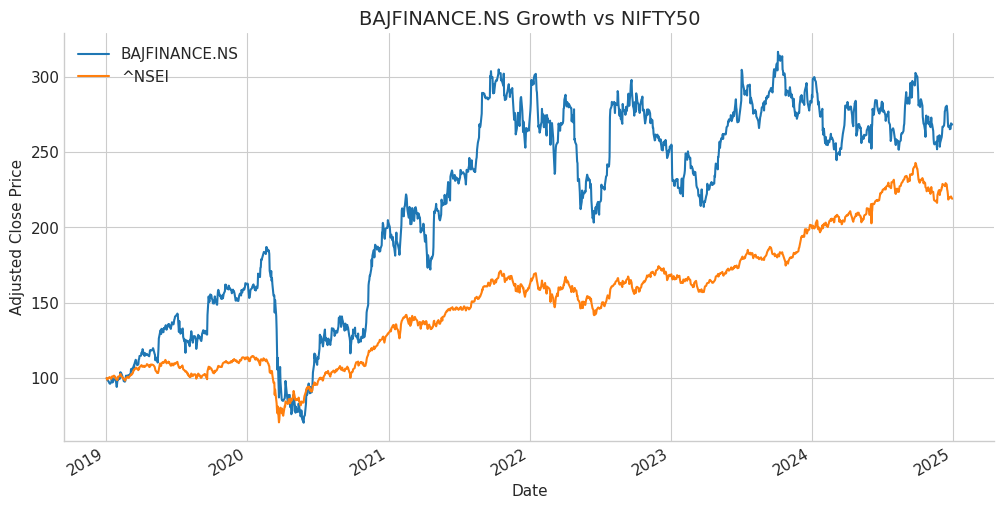

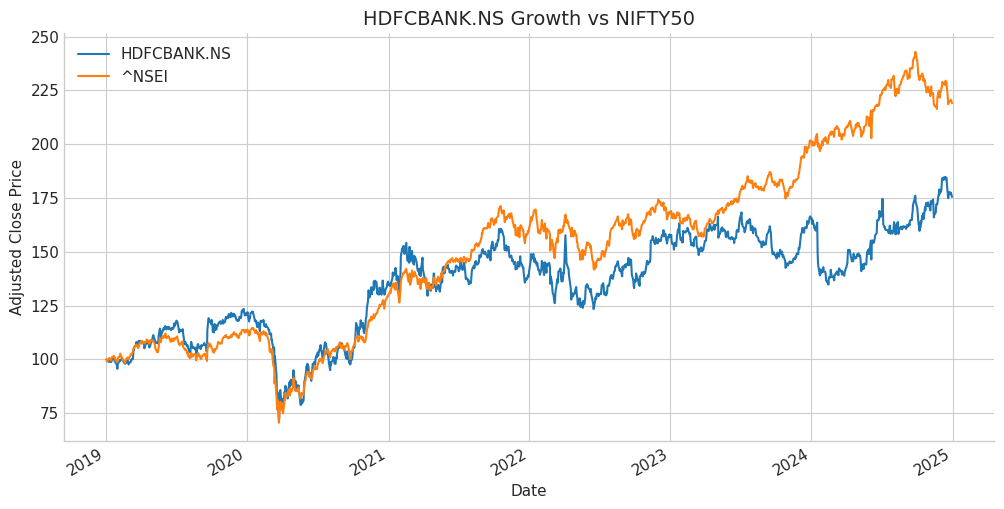

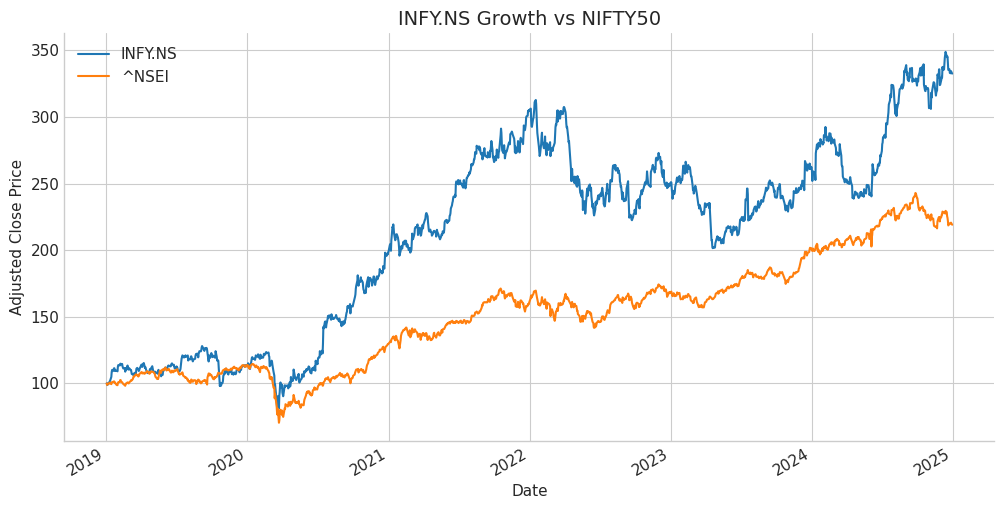

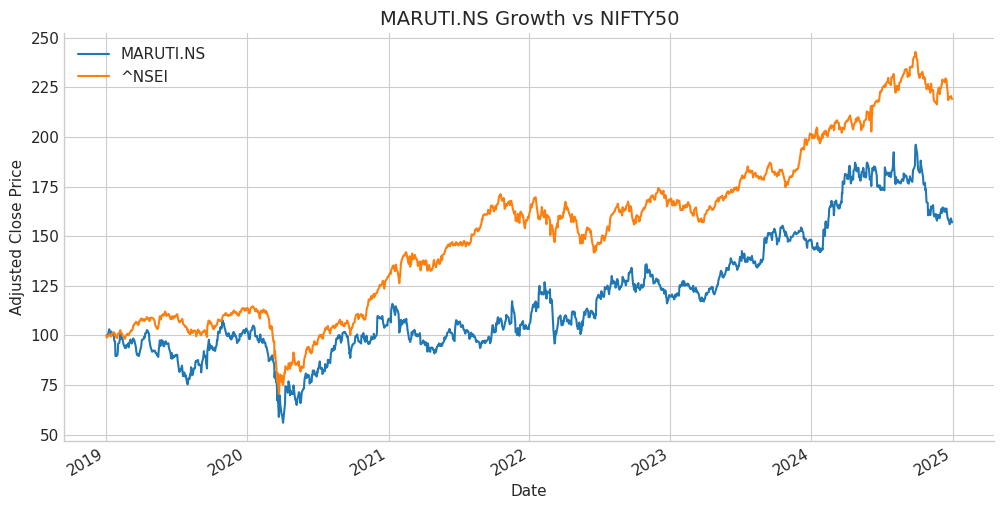

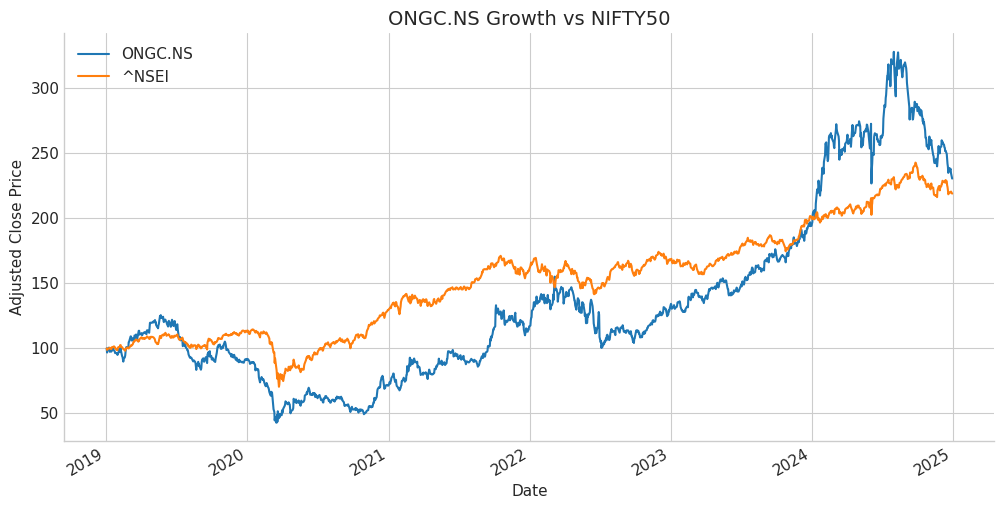

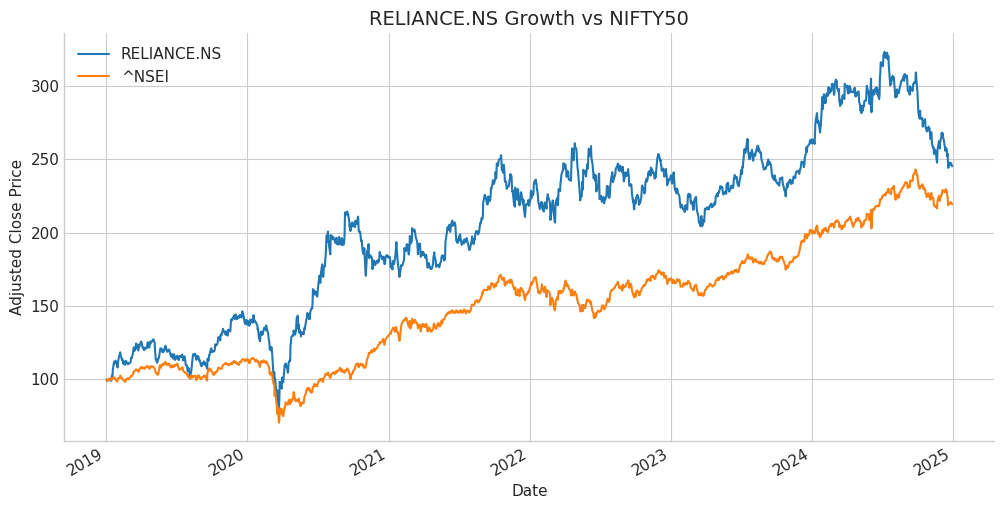

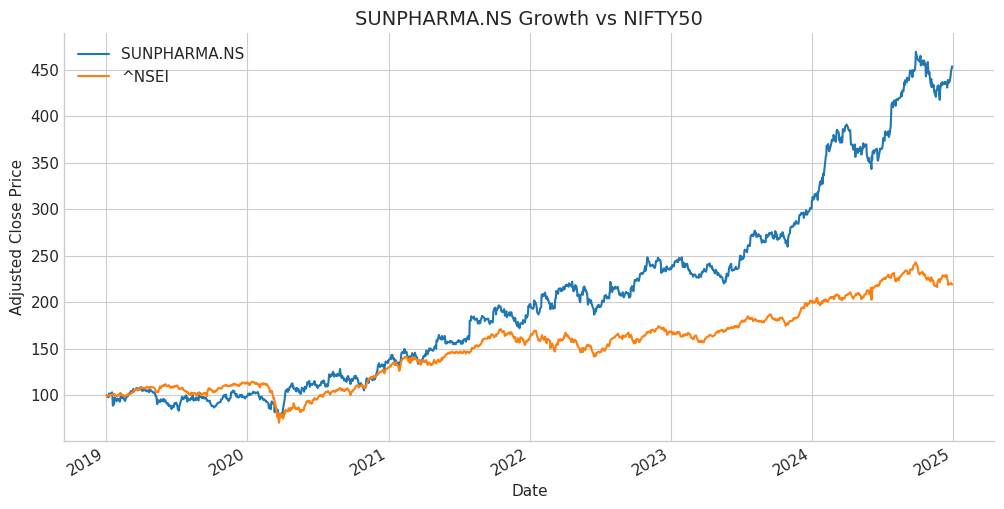

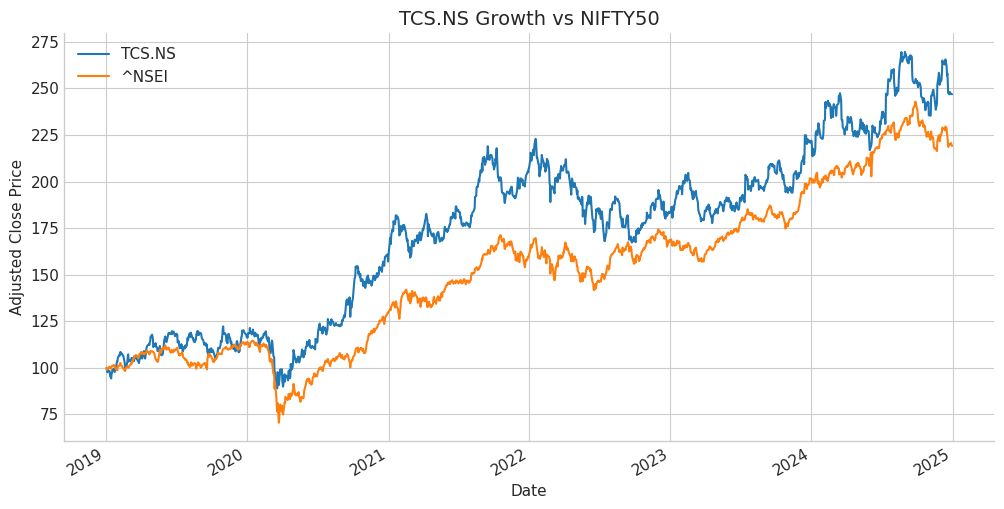

In [14]:
stocks = [col for col in clean.columns if col != '^NSEI']
for i in stocks:
    base100=clean[[i,'^NSEI']]/clean[[i,'^NSEI']].iloc[0]*100
    base100.plot(figsize=(12,6))
    plt.title(f"{i} Growth vs NIFTY50")
    plt.xlabel("Date")
    plt.ylabel("Adjusted Close Price")
    plt.grid(True)
    plt.legend(loc="upper left")
    plt.show()

In [15]:
log_returns=clean.pct_change().apply(lambda x: np.log(1+x)).dropna()
log_returns.head()

Ticker,ADANIENT.NS,ASIANPAINT.NS,BAJFINANCE.NS,HDFCBANK.NS,INFY.NS,MARUTI.NS,ONGC.NS,RELIANCE.NS,SUNPHARMA.NS,TCS.NS,^NSEI
Date,,,,,,,,,,,
2019-01-03,-0.015292,0.003608,-0.010711,-0.007877,0.000150,-0.008831,-0.032133,-0.012414,-0.009017,-0.012215,-0.011205
2019-01-04,0.000328,-0.001766,-0.003932,0.002672,-0.012179,0.004232,0.022910,0.005385,-0.005288,-0.012233,0.005150
2019-01-07,-0.008559,0.007297,-0.008753,0.001510,0.015983,0.017477,0.014649,0.005537,-0.006940,0.011153,0.004135
2019-01-08,0.014441,0.003754,-0.006502,-0.008358,-0.002460,0.010465,-0.002709,-0.000090,0.039261,-0.002295,0.002814
2019-01-09,-0.027082,0.000535,-0.005018,0.006541,0.008989,0.007152,-0.014688,0.005507,0.001561,-0.003491,0.004894


In [16]:
rolling_volatility=log_returns.rolling(21).std()*np.sqrt(252)

In [17]:
cumulative_returns=(1+log_returns).cumprod()
rolling_max=cumulative_returns.cummax()
drawdown=(cumulative_returns-rolling_max)/rolling_max

In [18]:
daily_risk_free_rate = 0.07/252
mean_return = log_returns.rolling(63).mean()
std_of_return = log_returns.rolling(63).std()
sharpe_ratio = ((mean_return - daily_risk_free_rate) / std_of_return )*np.sqrt(252)

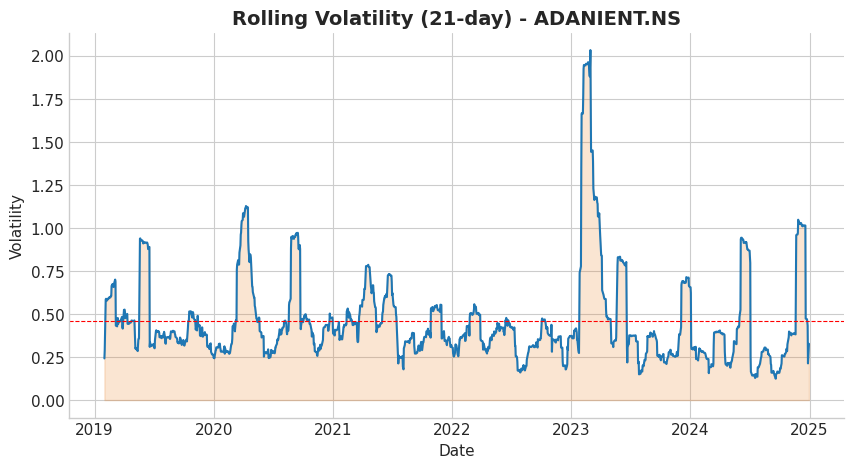

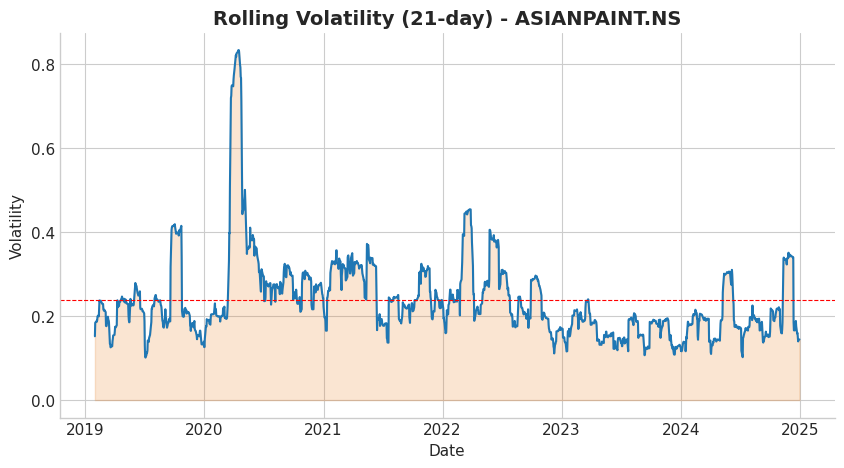

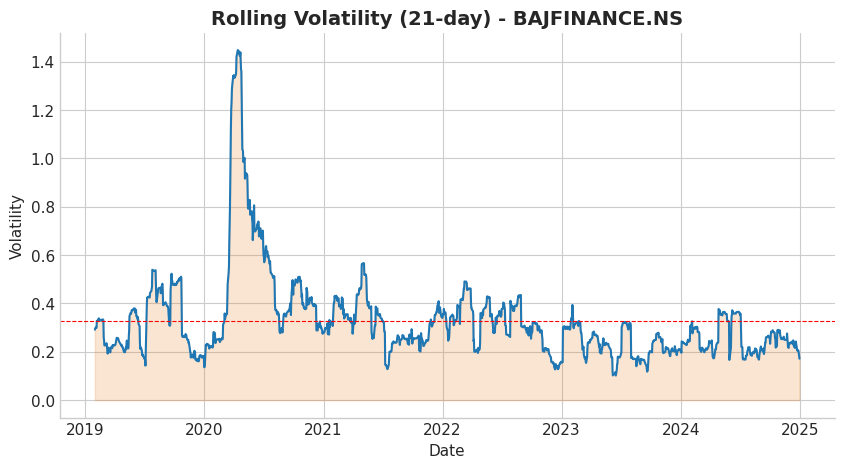

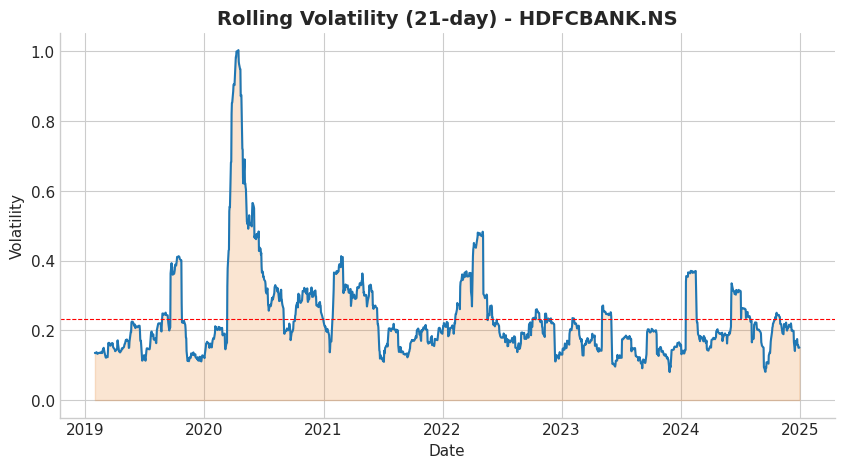

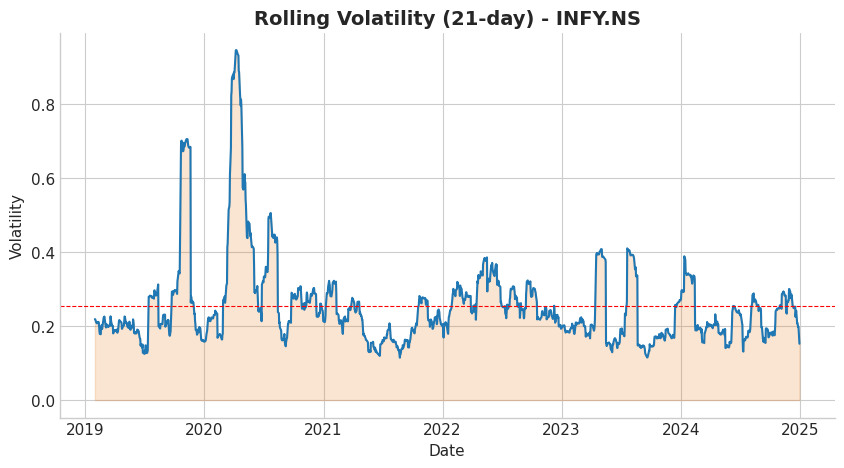

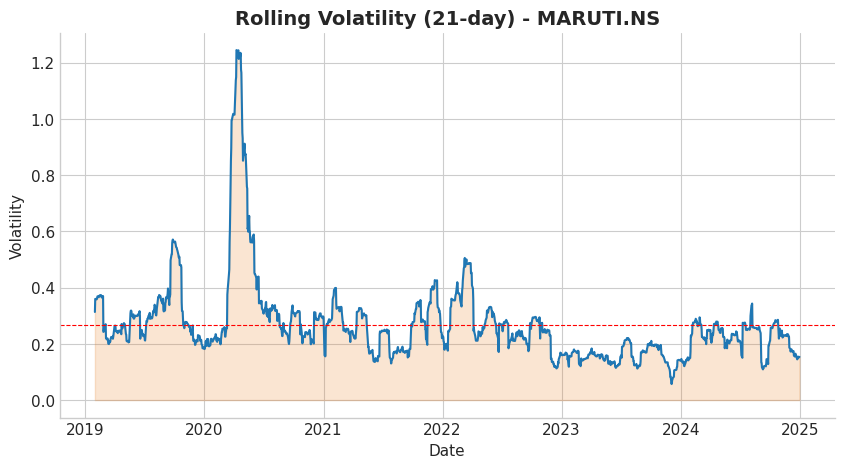

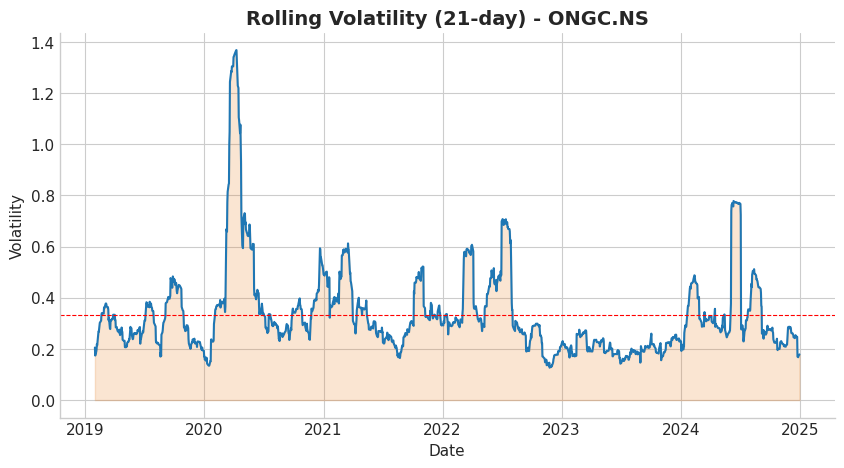

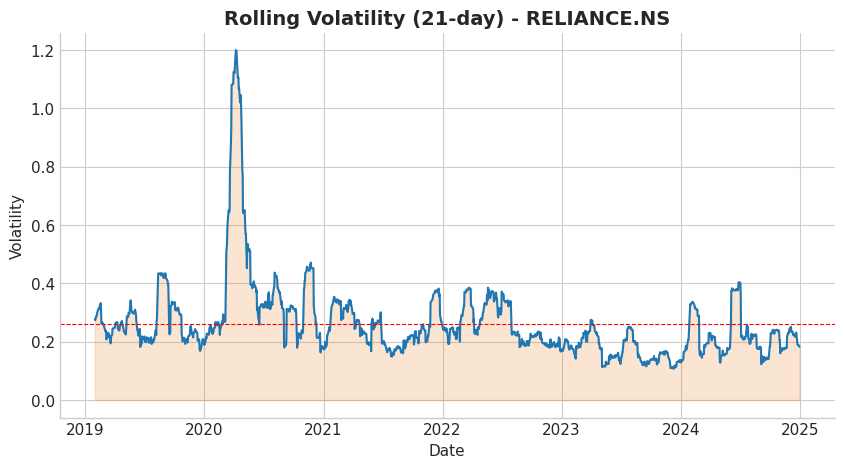

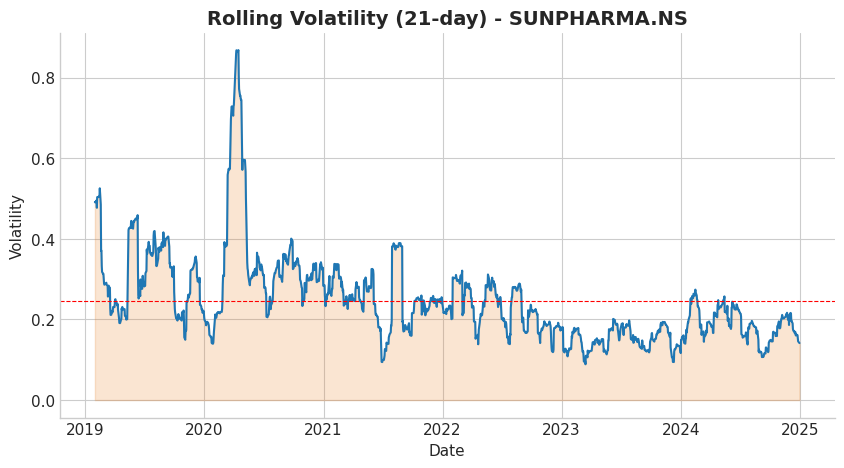

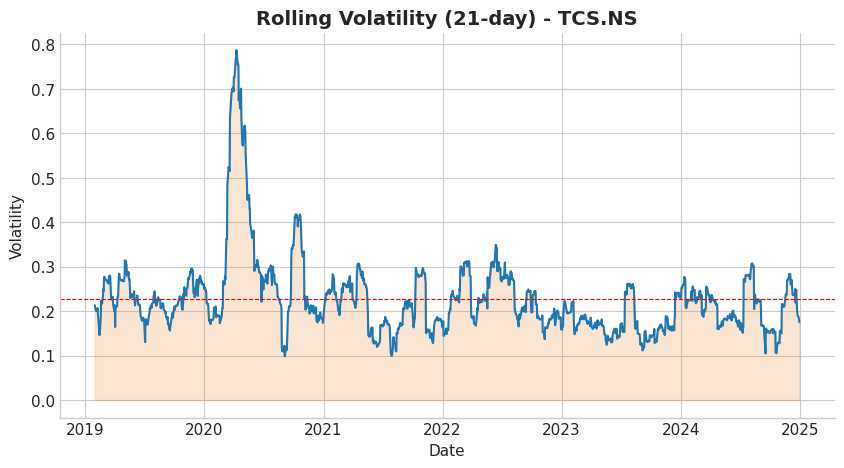

In [19]:
for i in stocks:
    fig,ax=plt.subplots(figsize=(10,5))
    ax.plot(rolling_volatility[i].index, rolling_volatility[i].values, label=f"{i} Volatility")
    ax.set_title("Rolling Volatility (21-day) - "+i,fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatility")
    ax.fill_between(rolling_volatility[i].index, rolling_volatility[i].values, color='#e67e22', alpha=0.2)
    ax.axhline(rolling_volatility[i].mean(), color='red', linestyle='--', linewidth=0.8, label='Average Volatility')
    ax.grid(True)
    plt.show()

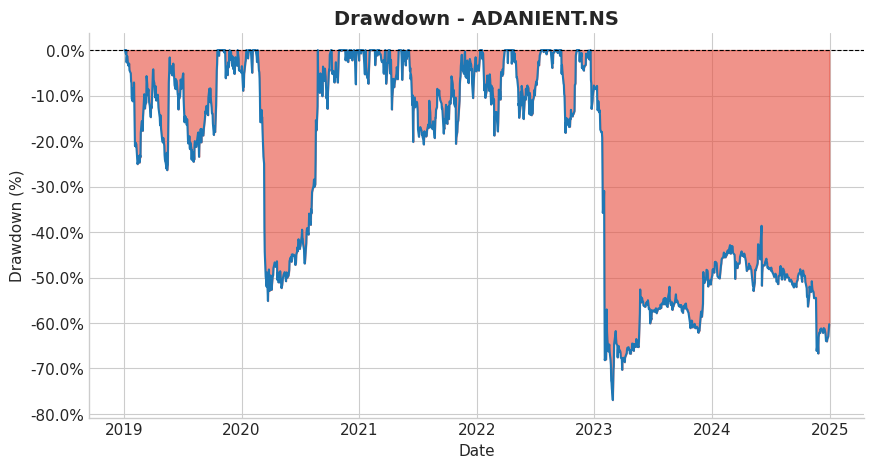

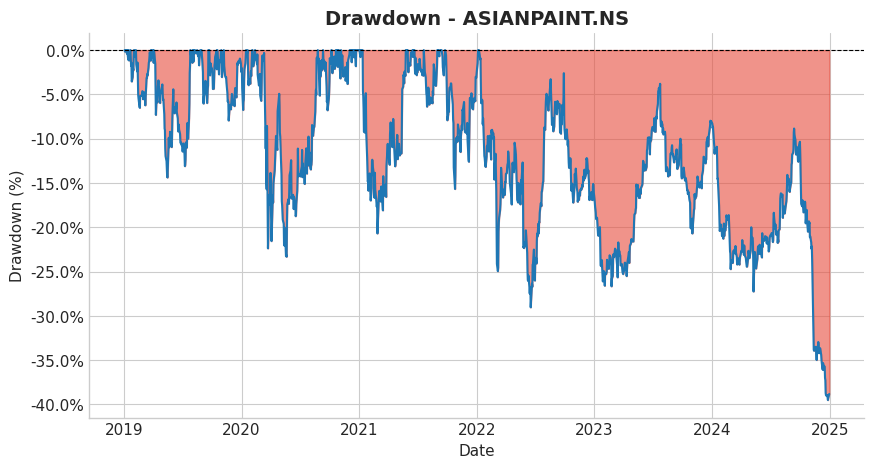

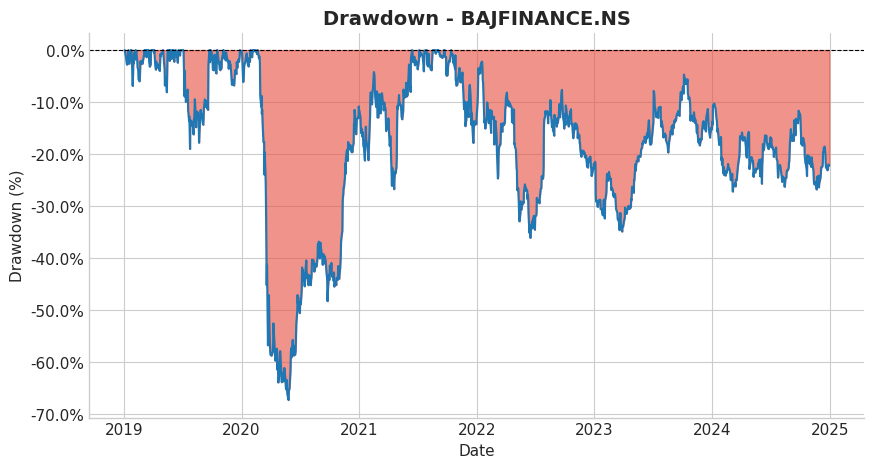

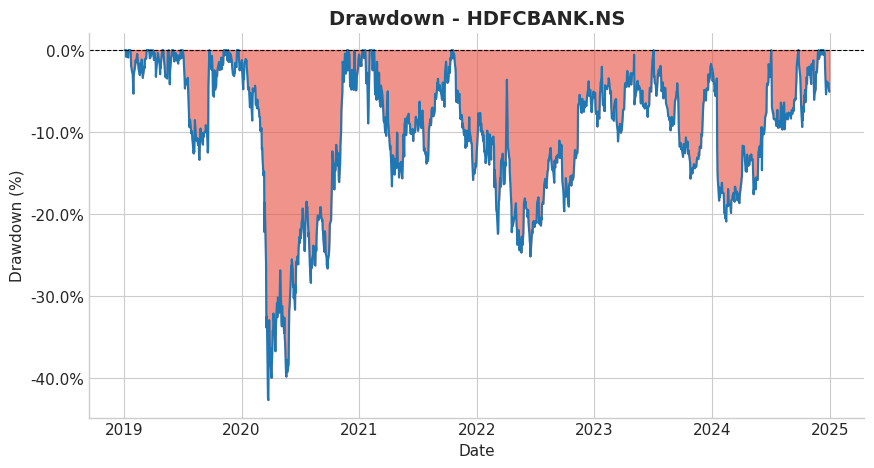

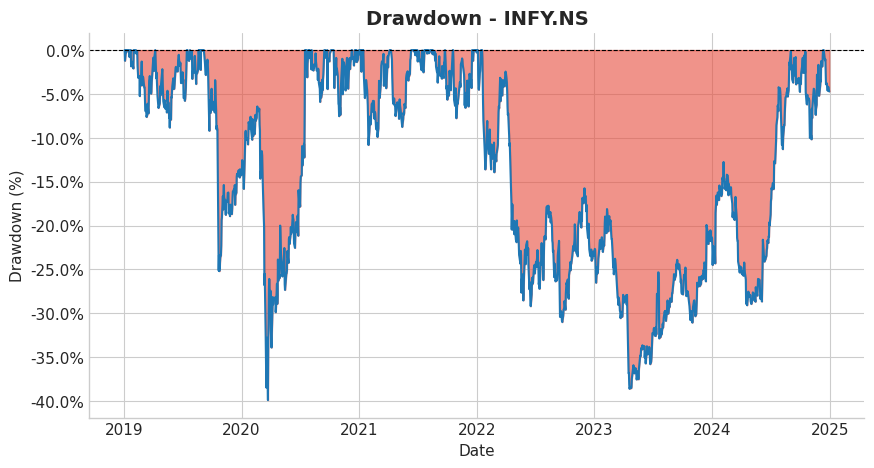

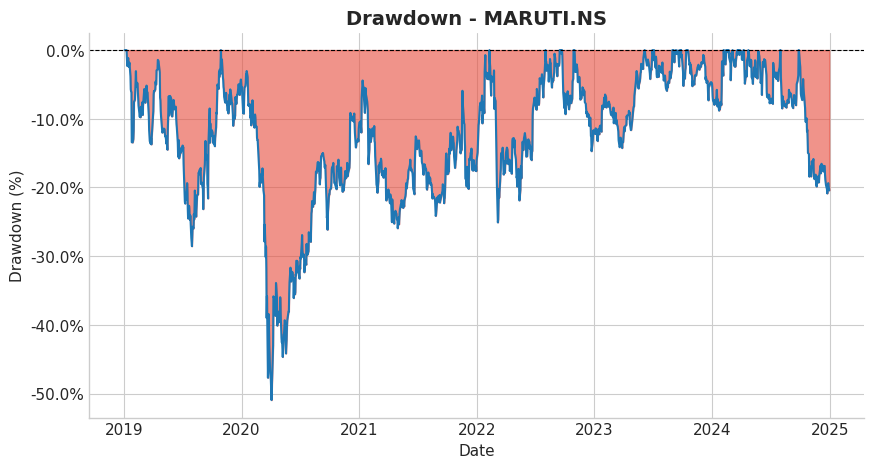

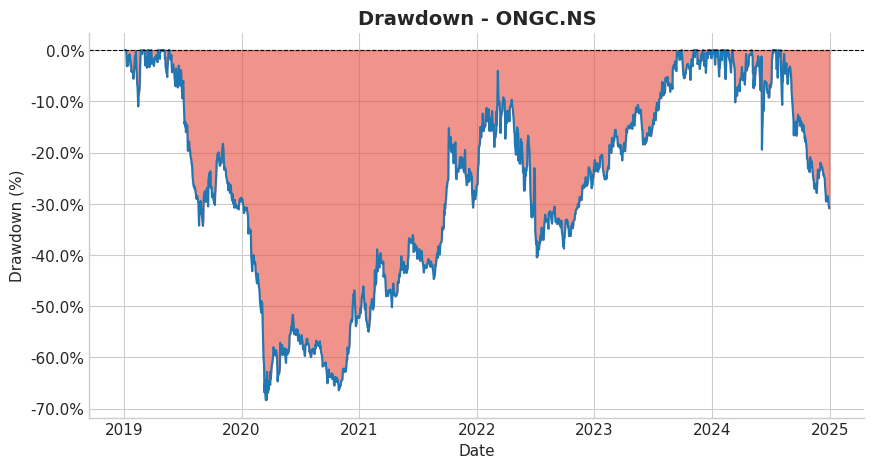

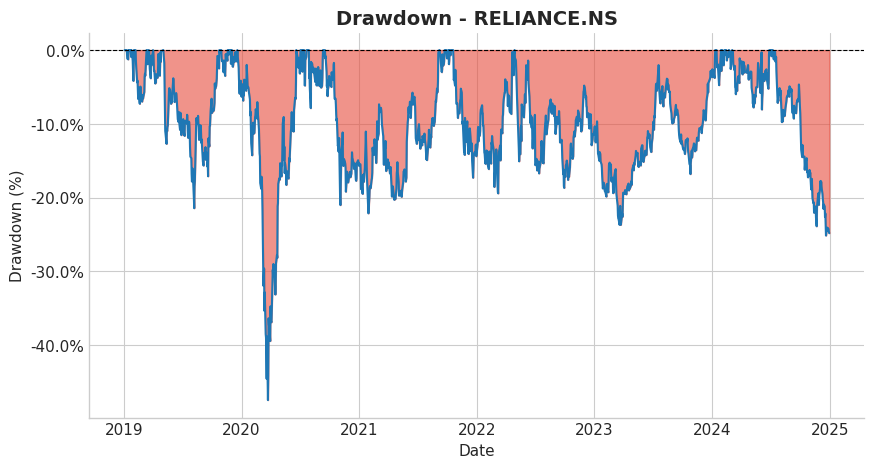

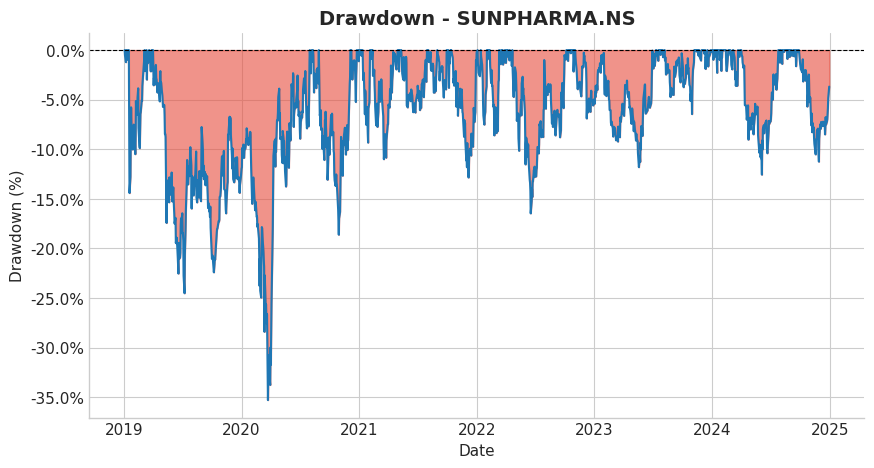

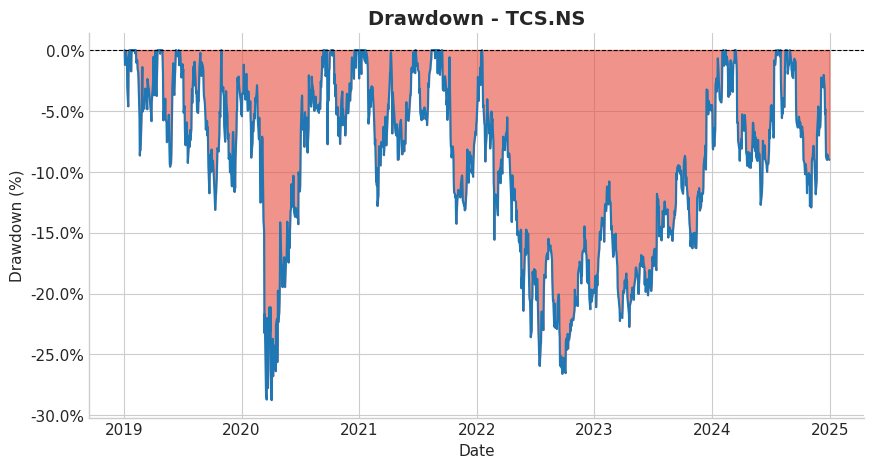

In [20]:
for i in stocks:
    fig,ax=plt.subplots(figsize=(10,5))
    ax.plot(drawdown[i], label=f"{i} Drawdown")
    ax.set_title("Drawdown - "+i,fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown (%)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))
    ax.fill_between(drawdown.index, drawdown[i], color='#e74c3c', alpha=0.6)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(True)
    plt.show()

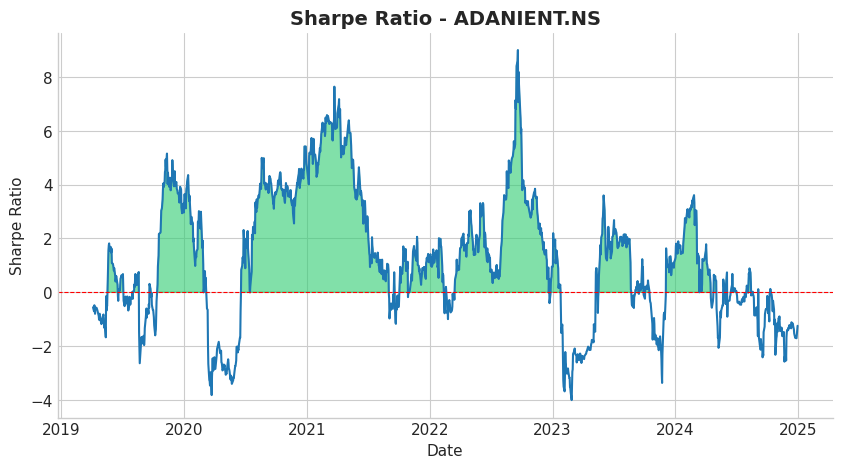

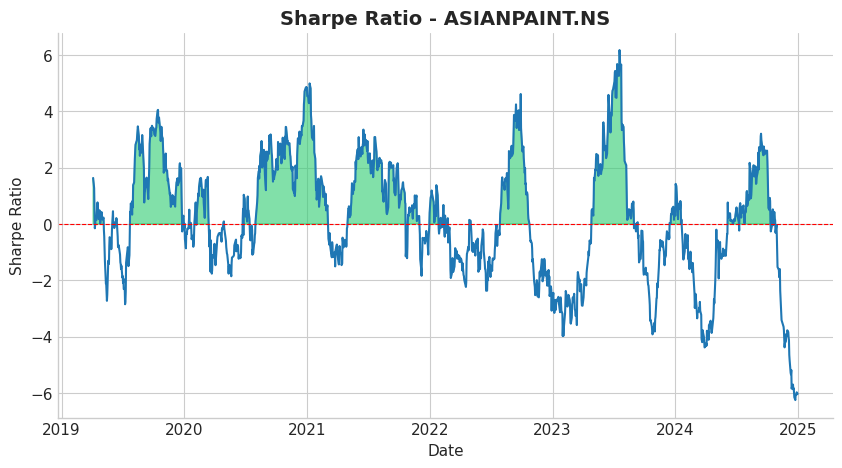

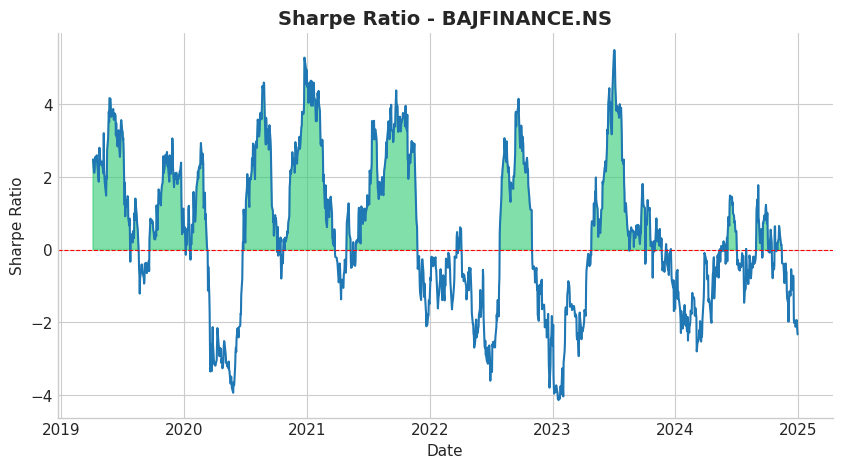

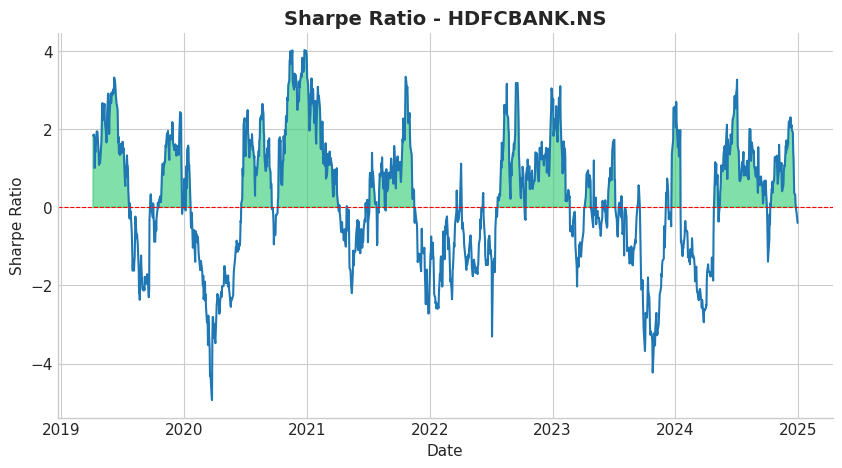

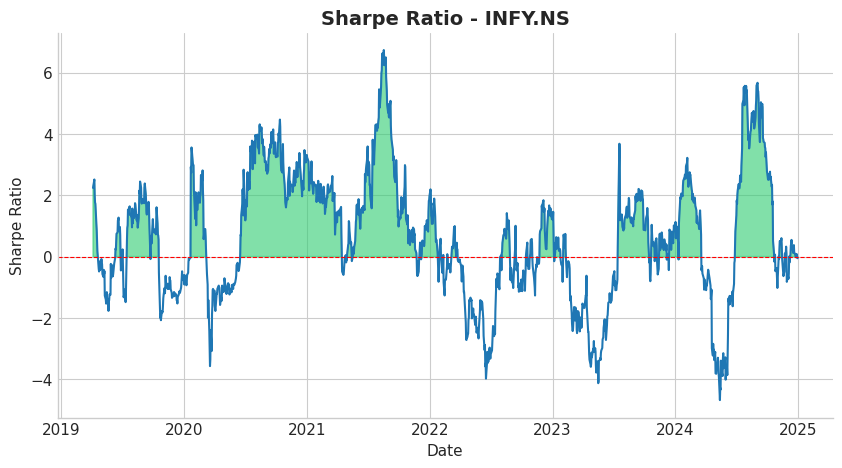

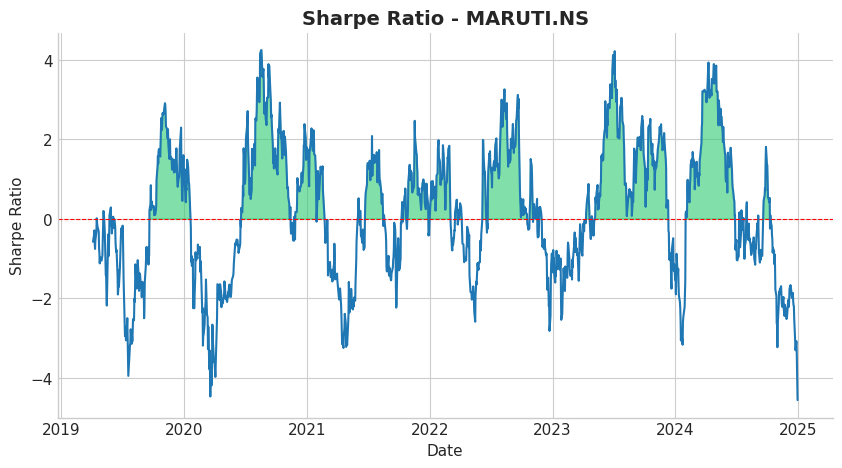

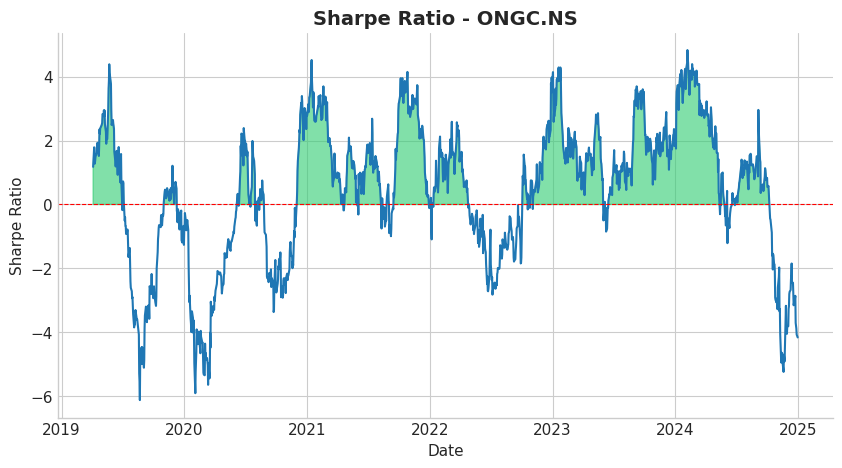

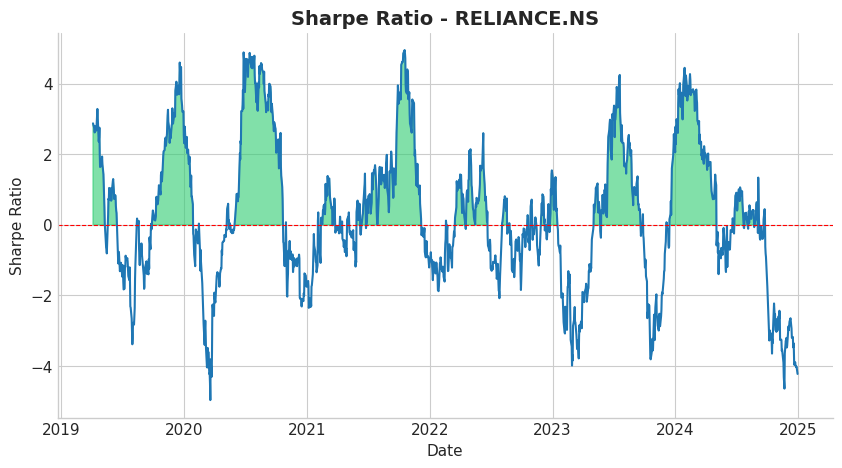

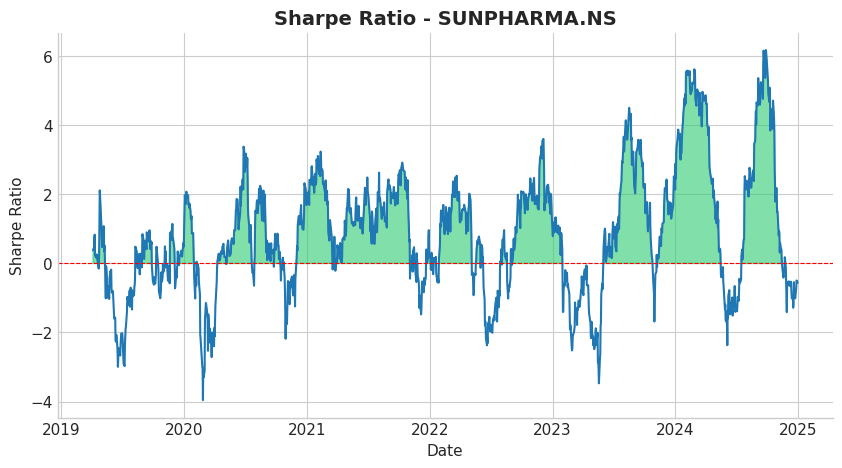

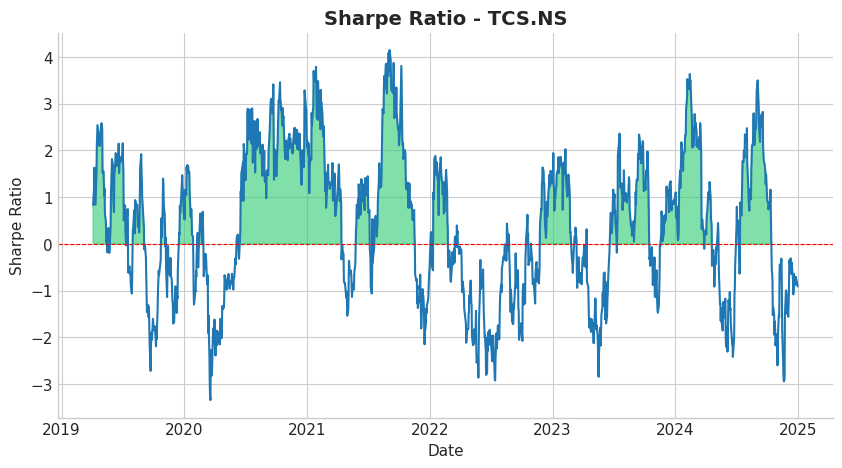

In [21]:
for i in stocks:
    fig,ax=plt.subplots(figsize=(10,5))
    ax.plot(sharpe_ratio[i], label=f"{i} Sharpe Ratio")
    ax.set_title("Sharpe Ratio - "+i,fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Sharpe Ratio")
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
    ax.fill_between(sharpe_ratio.index, sharpe_ratio[i], where=(sharpe_ratio[i] > 0), color='#2ecc71', alpha=0.6, interpolate=True)
    ax.grid(True)
    plt.show()

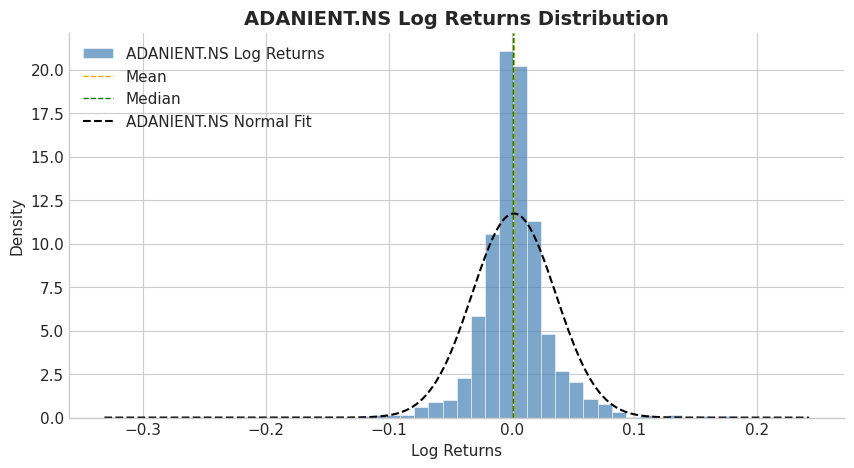

Kurtosis: 20.2851
Skewness: -1.1423


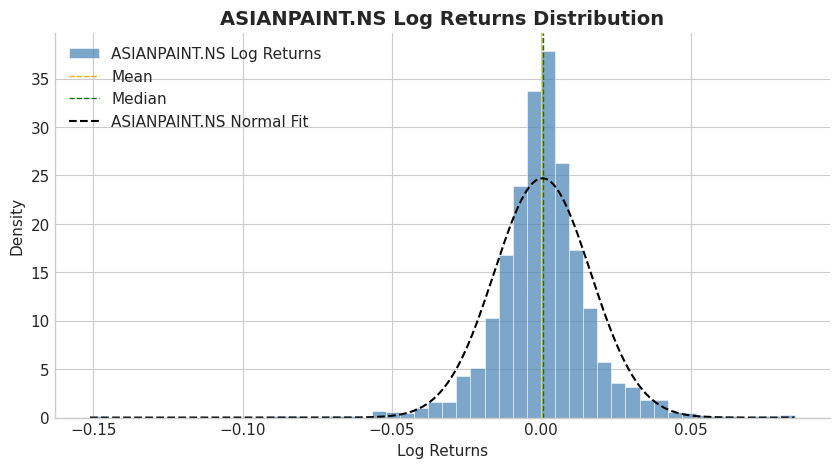

Kurtosis: 8.5231
Skewness: -0.4986


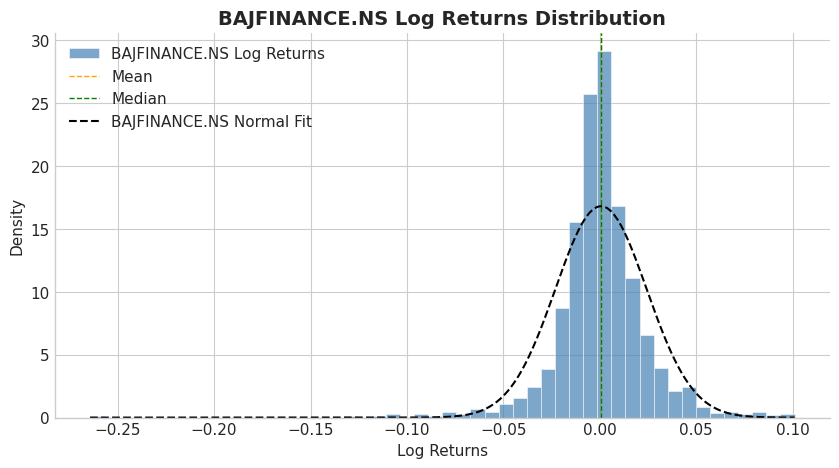

Kurtosis: 14.0634
Skewness: -1.1498


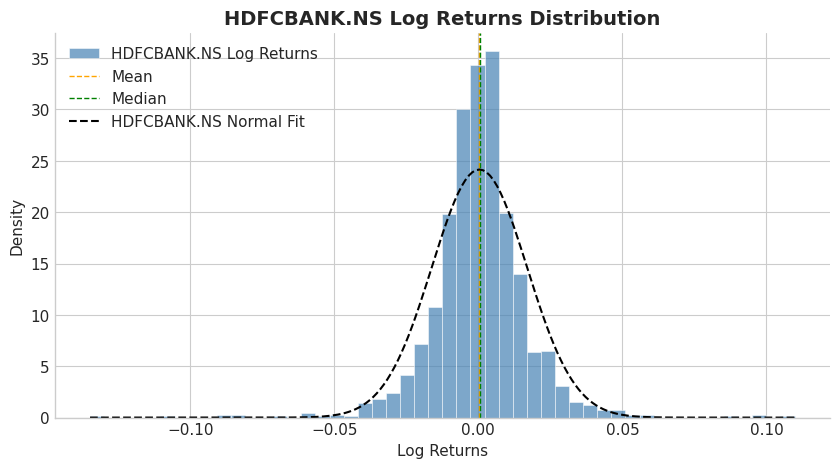

Kurtosis: 9.4811
Skewness: -0.3633


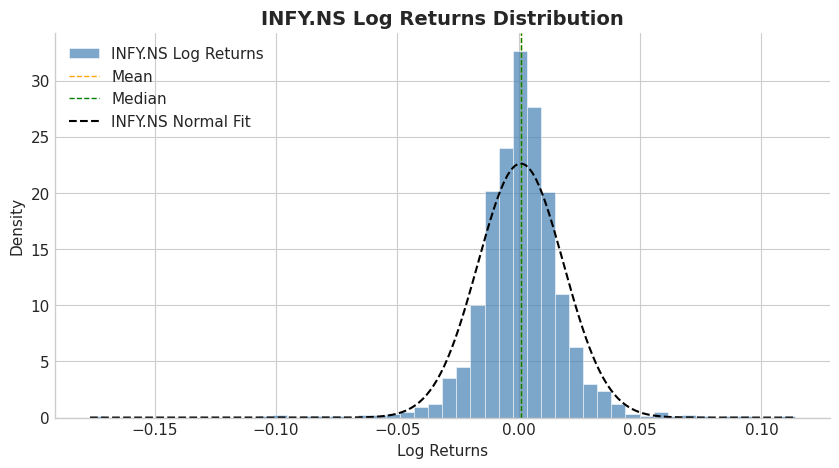

Kurtosis: 12.2188
Skewness: -0.7898


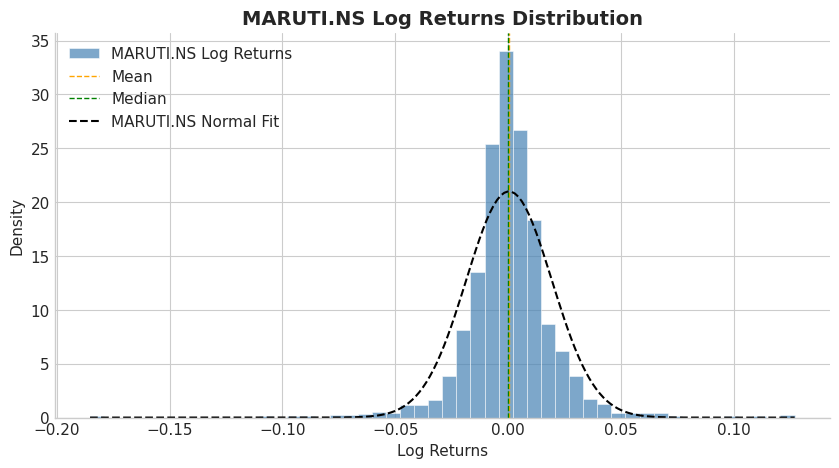

Kurtosis: 12.0195
Skewness: -0.2805


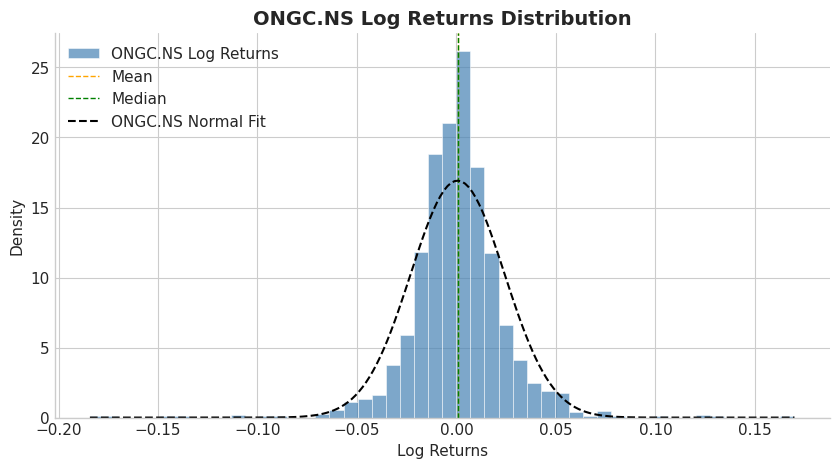

Kurtosis: 10.1449
Skewness: -0.3745


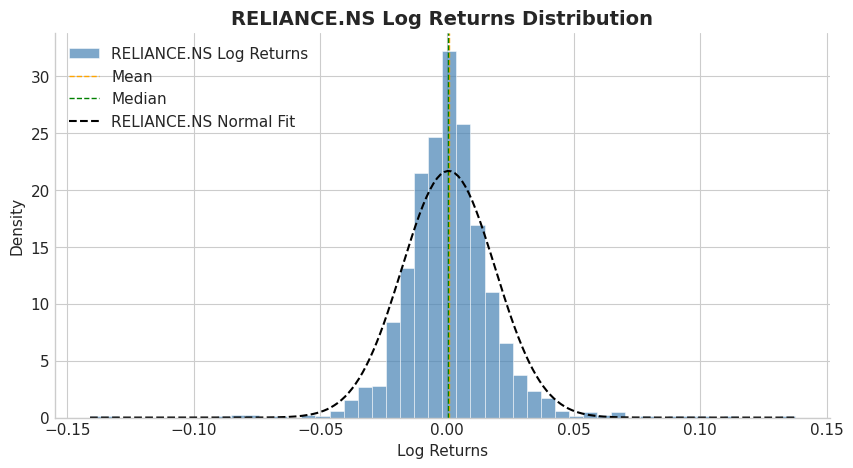

Kurtosis: 9.9098
Skewness: 0.1165


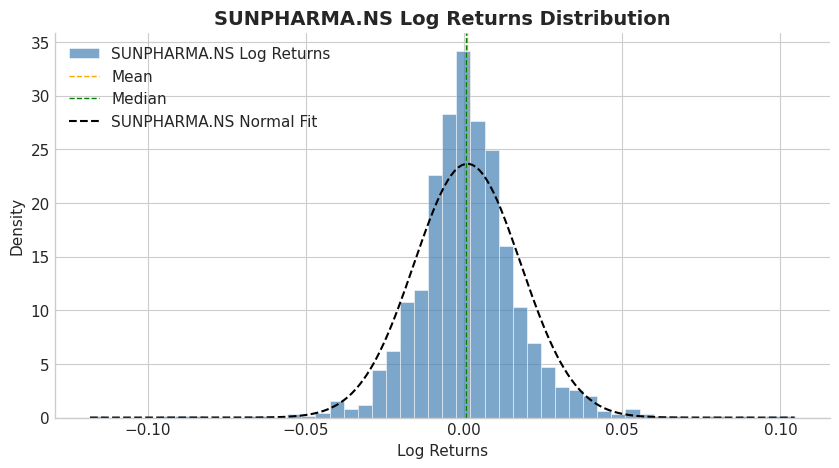

Kurtosis: 6.0320
Skewness: 0.0519


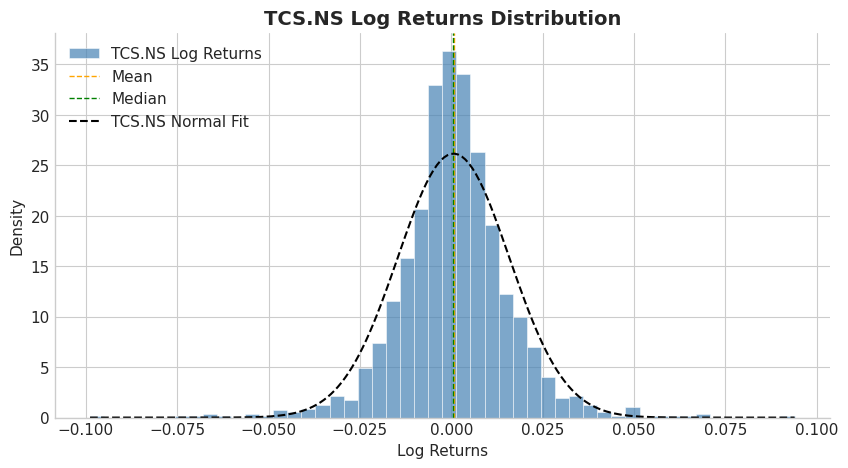

Kurtosis: 4.6201
Skewness: -0.1218


In [22]:
for i in stocks:
    fig,ax=plt.subplots(figsize=(10,5))
    ax.hist(log_returns[i], bins=50, density=True,color='steelblue', alpha=0.7, edgecolor='white',linewidth=0.5, label=f"{i} Log Returns")
    ax.axvline(log_returns[i].mean(), color='orange', linestyle='--', linewidth=1, label='Mean')
    ax.axvline(log_returns[i].median(), color='green', linestyle='--', linewidth=1, label='Median')
    ax.grid(True)
    mu,std=log_returns[i].mean(), log_returns[i].std()
    x=np.linspace(log_returns[i].min(), log_returns[i].max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, std),'k--', label=f"{i} Normal Fit")
    ax.legend(loc="upper left")
    plt.title(f"{i} Log Returns Distribution",fontweight='bold')
    plt.xlabel("Log Returns")
    plt.ylabel("Density")
    plt.show()
    print(f"Kurtosis: {log_returns[i].kurt():.4f}")
    print(f"Skewness: {log_returns[i].skew():.4f}")

##### High kurtosis doesn't mean higher average returns. It means extreme returns - both positive and negative - happen far more frequently than a normal distribution would predict

Text(0.5, 1.0, 'Correlation Heatmap of Log Returns')

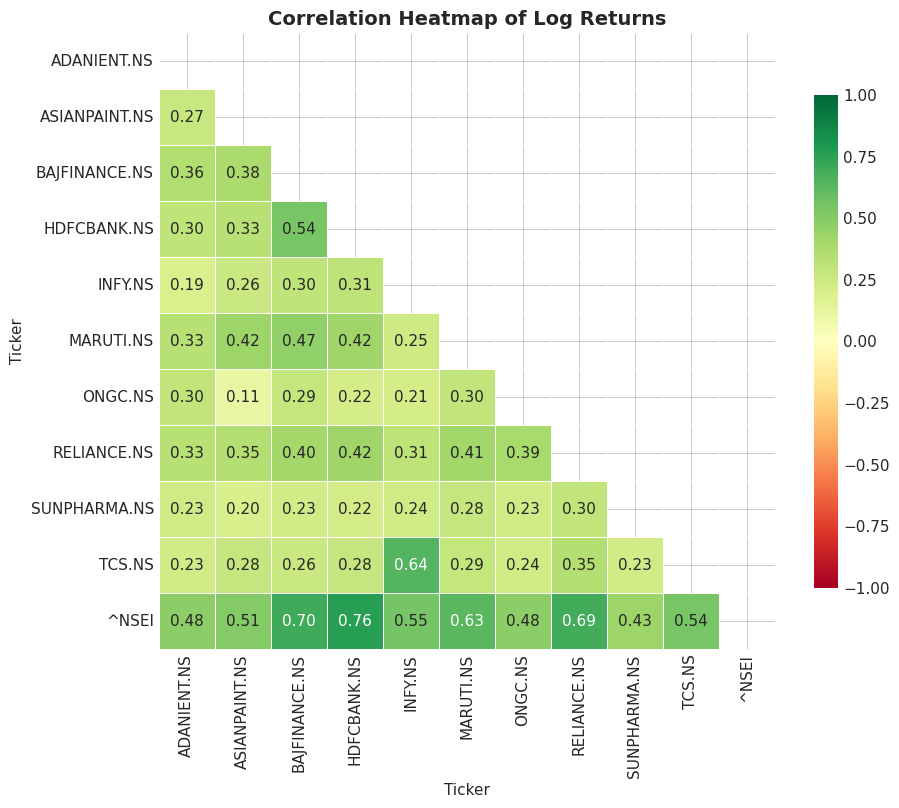

In [23]:
#Correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = log_returns.corr()
mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax, mask=mask,vmin=-1, vmax=1,square=True,
             linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap of Log Returns",fontweight='bold')